In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize
from functools import partial

In [1]:
''' 
# Current price
V = 1167.0
# Coupon price
c = 100.0
# Maturity
T = 3
# Exercise dates
Ti = np.arange(1, T + 1)
# PV
p = 1000.0
'''

' \n# Current price\nV = 1167.0\n# Coupon price\nc = 100.0\n# Maturity\nT = 3\n# Exercise dates\nTi = np.arange(1, T + 1)\n# PV\np = 1000.0\n'

In [63]:
def coupon_bond1(Ti, T, c, p, y, t):
    r = 0.0
    for ti in Ti:
        r += c / power(1 + y, ti)
    r += p / power(1 + y, T)
    return r
    
def coupon_bond2(Ti, T, c, p, y, t):
    r = 0.0
    for ti in Ti:
        r += c * np.exp(-y * (ti - t))
    r += p * np.exp(-y * (T - t))
    return r

def power(a, e):
    res = 1.0
    for i in range(e):
        res *= a
    return res
    

def P(t, y):
    return coupon_bond2([1, 2, 3], 3, 100.0, 1000.0, y, t) - coupon_bond2([1, 2, 3], 3, 100.0, 1000.0, 0.04, 0)

In [64]:
coupon_bond1([1, 2, 3], 3, 100.0, 1000.0, 0.04, 0), \
coupon_bond2([1, 2, 3], 3, 100.0, 1000.0, 0.04, 0)

(1166.5054619936275, np.float64(1164.0030589427693))

In [89]:
et = 4
ts = np.arange(1, et + 1)
coupon = 100.0
nom =  1000.0
r = 0.05

In [90]:
YTM = lambda t: optimize.newton(partial(P, t), 0.1, maxiter=10000)
Y = lambda t: coupon / coupon_bond2(ts, et, coupon, nom, 5, t)

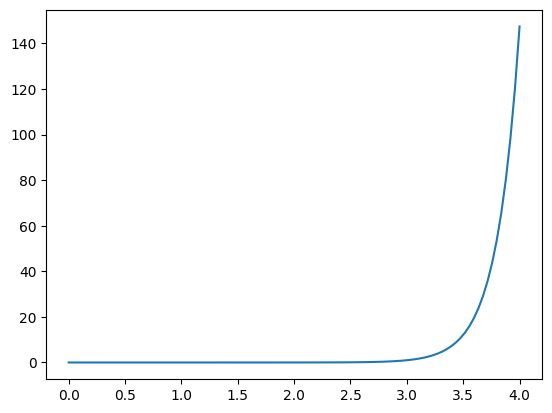

In [91]:
tt = np.linspace(0.0, et, 100)

YY = np.array([Y(et - t) for t in tt])

fig, ax = plt.subplots()
ax.plot(tt, YY)
plt.show()